In [12]:
# Verify PyTorch and CUDA
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torchattacks
import numpy as np
import time
import os
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu130
CUDA available: True
CUDA device: NVIDIA GeForce RTX 3050 Laptop GPU


In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data
batch_size = 128
num_workers = 2

# Training
epochs_standard = 200
epochs_at = 120          # fewer for adversarial training (converges faster)
epochs_finetune = 30     # for pruned model
lr = 0.1
momentum = 0.9
weight_decay = 5e-4

# Attack
eps = 8/255
alpha = 2/255
steps = 20

# Pruning
prune_amount = 0.5       # 50%

# Paths
os.makedirs("checkpoints", exist_ok=True)

Using device: cuda


In [14]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

transform_test = transforms.ToTensor()

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=num_workers)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=num_workers)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
print("Data loaded successfully.")

Data loaded successfully.


In [18]:
def accuracy(output, target, topk=(1,)):
    """Computes the accuracy over the k top predictions"""
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)

        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))

        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size))
        return res

def train_one_epoch(model, loader, optimizer, criterion, epoch, atk=None):
    model.train()
    train_loss = 0
    correct = 0
    total = 0
    pbar = tqdm(loader, desc=f"Epoch {epoch}")
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        if atk is not None:
            # Generate adversarial examples on the fly
            model.eval()  # atk requires model in eval mode for gradient computation
            inputs = atk(inputs, targets)
            model.train()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        pbar.set_postfix({'loss': train_loss/total, 'acc': 100.*correct/total})
    return train_loss/total, 100.*correct/total

def evaluate(model, loader, atk=None):
    model.eval()
    correct = 0
    total = 0
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        if atk is not None:
            # Enable gradients for the attack
            inputs.requires_grad = True
            adv_inputs = atk(inputs, targets)
            # Remove gradients before feeding to model
            inputs = adv_inputs.detach()
        with torch.no_grad():
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return 100. * correct / total

def save_checkpoint(model, filename):
    torch.save(model.state_dict(), filename)

def load_checkpoint(model, filename):
    model.load_state_dict(torch.load(filename))
    return model

def count_zero_params(model):
    total = 0
    zero = 0
    for param in model.parameters():
        total += param.numel()
        zero += (param == 0).sum().item()
    return zero / total * 100

In [16]:
print("\n=== 1. Training Standard ResNet-18 ===")
model_std = torchvision.models.resnet18(pretrained=False, num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model_std.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_standard)

best_acc = 0
for epoch in range(1, epochs_standard + 1):
    loss, acc = train_one_epoch(model_std, trainloader, optimizer, criterion, epoch)
    scheduler.step()
    if epoch % 10 == 0 or epoch == epochs_standard:
        clean_acc = evaluate(model_std, testloader)
        print(f"Epoch {epoch}: Clean test accuracy = {clean_acc:.2f}%")
        if clean_acc > best_acc:
            best_acc = clean_acc
            save_checkpoint(model_std, "checkpoints/resnet18_standard_best.pth")
print(f"Best clean accuracy: {best_acc:.2f}%")

# Load best model
model_std = load_checkpoint(torchvision.models.resnet18(pretrained=False, num_classes=10).to(device),
                            "checkpoints/resnet18_standard_best.pth")


=== 1. Training Standard ResNet-18 ===


Epoch 10: 100%|██████████| 391/391 [00:35<00:00, 11.09it/s, loss=0.855, acc=70.2]


Epoch 10: Clean test accuracy = 65.26%


Epoch 20: 100%|██████████| 391/391 [00:31<00:00, 12.30it/s, loss=0.731, acc=75]  


Epoch 20: Clean test accuracy = 50.23%


...

Epoch 180: Clean test accuracy = 88.06%


Epoch 190: 100%|██████████| 391/391 [00:28<00:00, 13.53it/s, loss=0.0327, acc=98.9]


Epoch 190: Clean test accuracy = 88.45%


Epoch 200: 100%|██████████| 391/391 [00:28<00:00, 13.49it/s, loss=0.0266, acc=99.2]


Epoch 200: Clean test accuracy = 88.77%
Best clean accuracy: 88.77%


In [19]:
pgd_atk = torchattacks.PGD(model_std, eps=eps, alpha=alpha, steps=steps)
robust_acc = evaluate(model_std, testloader, atk=pgd_atk)
print(f"Standard model robust accuracy under PGD-{steps}: {robust_acc:.2f}%")

Standard model robust accuracy under PGD-20: 0.37%


In [20]:
print("\n=== 2. Training PGD-AT ResNet-18 ===")
model_at = torchvision.models.resnet18(pretrained=False, num_classes=10).to(device)
optimizer = optim.SGD(model_at.parameters(), lr=lr, momentum=momentum, weight_decay=weight_decay)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs_at)
train_atk = torchattacks.PGD(model_at, eps=eps, alpha=alpha, steps=10)  # use 10-step during training for speed

best_acc = 0
for epoch in range(1, epochs_at + 1):
    loss, acc = train_one_epoch(model_at, trainloader, optimizer, criterion, epoch, atk=train_atk)
    scheduler.step()
    if epoch % 10 == 0 or epoch == epochs_at:
        clean_acc = evaluate(model_at, testloader)
        robust_acc = evaluate(model_at, testloader, atk=pgd_atk)
        print(f"Epoch {epoch}: Clean = {clean_acc:.2f}%, Robust (PGD-20) = {robust_acc:.2f}%")
        if robust_acc > best_acc:
            best_acc = robust_acc
            save_checkpoint(model_at, "checkpoints/resnet18_at_best.pth")
print(f"Best robust accuracy (PGD-20): {best_acc:.2f}%")

# Load best robust model
model_at = load_checkpoint(torchvision.models.resnet18(pretrained=False, num_classes=10).to(device),
                           "checkpoints/resnet18_at_best.pth")


=== 2. Training PGD-AT ResNet-18 ===


Epoch 10: 100%|██████████| 391/391 [01:22<00:00,  4.73it/s, loss=1.84, acc=30.9]


Epoch 10: Clean = 44.95%, Robust (PGD-20) = 44.26%


Epoch 20: 100%|██████████| 391/391 [01:21<00:00,  4.79it/s, loss=1.75, acc=34.5]


Epoch 20: Clean = 56.32%, Robust (PGD-20) = 54.77%


...

Epoch 100: Clean = 71.08%, Robust (PGD-20) = 69.00%


Epoch 110: 100%|██████████| 391/391 [01:23<00:00,  4.70it/s, loss=1.23, acc=50.6]


Epoch 110: Clean = 72.72%, Robust (PGD-20) = 70.59%


Epoch 120: 100%|██████████| 391/391 [01:21<00:00,  4.79it/s, loss=1.15, acc=53]  


Epoch 120: Clean = 73.34%, Robust (PGD-20) = 71.12%
Best robust accuracy (PGD-20): 71.12%


In [21]:
print("\n=== 3. Pruning Standard Model (50%) + Fine-tuning ===")
model_pruned = torchvision.models.resnet18(pretrained=False, num_classes=10).to(device)
# Load the standard pre-trained weights
model_pruned = load_checkpoint(model_pruned, "checkpoints/resnet18_standard_best.pth")

# Apply unstructured L1 pruning to all Conv2d and Linear layers
for name, module in model_pruned.named_modules():
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name='weight', amount=prune_amount)
        prune.remove(module, 'weight')  # make pruning permanent

sparsity = count_zero_params(model_pruned)
print(f"Model sparsity: {sparsity:.2f}%")

# Evaluate pruned model without fine-tuning
clean_acc_pruned = evaluate(model_pruned, testloader)
robust_acc_pruned = evaluate(model_pruned, testloader, atk=pgd_atk)
print(f"Pruned model (no FT) - Clean: {clean_acc_pruned:.2f}%, Robust: {robust_acc_pruned:.2f}%")

# Fine-tune pruned model with standard training
print("\n--- Fine-tuning pruned model (standard) ---")
optimizer_ft = optim.SGD(model_pruned.parameters(), lr=lr*0.1, momentum=momentum, weight_decay=weight_decay)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ft, T_max=epochs_finetune)
for epoch in range(1, epochs_finetune + 1):
    loss, acc = train_one_epoch(model_pruned, trainloader, optimizer_ft, criterion, epoch)
    scheduler_ft.step()
    if epoch % 10 == 0 or epoch == epochs_finetune:
        clean_acc = evaluate(model_pruned, testloader)
        robust_acc = evaluate(model_pruned, testloader, atk=pgd_atk)
        print(f"Epoch {epoch}: Clean = {clean_acc:.2f}%, Robust = {robust_acc:.2f}%")
save_checkpoint(model_pruned, "checkpoints/resnet18_pruned_ft_standard.pth")

# Also try adversarial fine-tuning
print("\n--- Fine-tuning pruned model (adversarial) ---")
model_pruned_at = torchvision.models.resnet18(pretrained=False, num_classes=10).to(device)
model_pruned_at = load_checkpoint(model_pruned_at, "checkpoints/resnet18_standard_best.pth")
# Prune again
for name, module in model_pruned_at.named_modules():
    if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
        prune.l1_unstructured(module, name='weight', amount=prune_amount)
        prune.remove(module, 'weight')
optimizer_at = optim.SGD(model_pruned_at.parameters(), lr=lr*0.1, momentum=momentum, weight_decay=weight_decay)
scheduler_at = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_at, T_max=epochs_finetune)
train_atk_ft = torchattacks.PGD(model_pruned_at, eps=eps, alpha=alpha, steps=10)
for epoch in range(1, epochs_finetune + 1):
    loss, acc = train_one_epoch(model_pruned_at, trainloader, optimizer_at, criterion, epoch, atk=train_atk_ft)
    scheduler_at.step()
    if epoch % 10 == 0 or epoch == epochs_finetune:
        clean_acc = evaluate(model_pruned_at, testloader)
        robust_acc = evaluate(model_pruned_at, testloader, atk=pgd_atk)
        print(f"Epoch {epoch}: Clean = {clean_acc:.2f}%, Robust = {robust_acc:.2f}%")
save_checkpoint(model_pruned_at, "checkpoints/resnet18_pruned_ft_adversarial.pth")


=== 3. Pruning Standard Model (50%) + Fine-tuning ===
Model sparsity: 49.96%
Pruned model (no FT) - Clean: 85.80%, Robust: 1.17%

--- Fine-tuning pruned model (standard) ---


Epoch 10: 100%|██████████| 391/391 [00:28<00:00, 13.52it/s, loss=0.173, acc=93.9]


Epoch 10: Clean = 78.88%, Robust = 10.96%


Epoch 20: 100%|██████████| 391/391 [00:30<00:00, 12.63it/s, loss=0.0731, acc=97.5]


Epoch 20: Clean = 87.07%, Robust = 3.27%


...

Epoch 10: Clean = 66.23%, Robust = 62.88%


Epoch 20: 100%|██████████| 391/391 [01:23<00:00,  4.69it/s, loss=1.53, acc=41.7]


Epoch 20: Clean = 68.87%, Robust = 66.10%


Epoch 30: 100%|██████████| 391/391 [01:22<00:00,  4.72it/s, loss=1.47, acc=43.3]


Epoch 30: Clean = 71.06%, Robust = 67.94%


In [ ]:
print("\n=== 4. Ensemble of 3 pruned (adversarially fine-tuned) models ===")
# We'll create 3 models with different random seeds to simulate diversity
ensemble_models = []
seeds = [42, 123, 999]
for seed in seeds:
    torch.manual_seed(seed)
    model = torchvision.models.resnet18(pretrained=False, num_classes=10).to(device)
    # Load standard pretrained weights
    model = load_checkpoint(model, "checkpoints/resnet18_standard_best.pth")
    # Prune
    for name, module in model.named_modules():
        if isinstance(module, nn.Conv2d) or isinstance(module, nn.Linear):
            prune.l1_unstructured(module, name='weight', amount=prune_amount)
            prune.remove(module, 'weight')
    # Adversarially fine-tune
    optimizer_ens = optim.SGD(model.parameters(), lr=lr*0.1, momentum=momentum, weight_decay=weight_decay)
    scheduler_ens = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ens, T_max=epochs_finetune)
    train_atk_ens = torchattacks.PGD(model, eps=eps, alpha=alpha, steps=10)
    for epoch in range(1, epochs_finetune + 1):
        train_one_epoch(model, trainloader, optimizer_ens, criterion, epoch, atk=train_atk_ens)
        scheduler_ens.step()
    ensemble_models.append(model)
    save_checkpoint(model, f"checkpoints/resnet18_pruned_ens_seed{seed}.pth")



=== 4. Ensemble of 3 pruned (adversarially fine-tuned) models ===


Epoch 30: 100%|██████████| 391/391 [01:12<00:00,  5.39it/s, loss=1.48, acc=42.8]


RuntimeError: element 0 of tensors does not require grad and does not have a grad_fn

In [25]:
def evaluate_ensemble(models, loader, atk=None):
    for m in models:
        m.eval()
    correct = 0
    total = 0
    
    for inputs, targets in loader:
        inputs, targets = inputs.to(device), targets.to(device)
        
        if atk is not None:
            # Enable gradients for attack generation
            inputs.requires_grad = True
            adv_inputs = atk(inputs, targets)
            # Detach to remove gradients before evaluation
            inputs = adv_inputs.detach()
        
        # Now evaluate the ensemble without gradients
        with torch.no_grad():
            outputs = torch.zeros(inputs.size(0), 10).to(device)
            for m in models:
                outputs += m(inputs)
            outputs /= len(models)
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    return 100. * correct / total

clean_acc_ens = evaluate_ensemble(ensemble_models, testloader)
robust_acc_ens = evaluate_ensemble(ensemble_models, testloader, atk=pgd_atk)
print(f"Ensemble - Clean: {clean_acc_ens:.2f}%, Robust: {robust_acc_ens:.2f}%")

Ensemble - Clean: 71.12%, Robust: 67.76%


In [26]:
print("\n=== Baseline Summary ===")
print(f"Standard model          : Clean={evaluate(model_std, testloader):.2f}%, Robust={evaluate(model_std, testloader, atk=pgd_atk):.2f}%")
print(f"PGD-AT model            : Clean={evaluate(model_at, testloader):.2f}%, Robust={evaluate(model_at, testloader, atk=pgd_atk):.2f}%")
print(f"Pruned (50% + std FT)   : Clean={evaluate(model_pruned, testloader):.2f}%, Robust={evaluate(model_pruned, testloader, atk=pgd_atk):.2f}%")
print(f"Pruned (50% + adv FT)   : Clean={evaluate(model_pruned_at, testloader):.2f}%, Robust={evaluate(model_pruned_at, testloader, atk=pgd_atk):.2f}%")
print(f"Ensemble (3 pruned+adv) : Clean={clean_acc_ens:.2f}%, Robust={robust_acc_ens:.2f}%")


=== Baseline Summary ===
Standard model          : Clean=88.77%, Robust=0.39%
PGD-AT model            : Clean=73.34%, Robust=71.17%
Pruned (50% + std FT)   : Clean=88.33%, Robust=2.01%
Pruned (50% + adv FT)   : Clean=71.06%, Robust=67.86%
Ensemble (3 pruned+adv) : Clean=71.12%, Robust=67.76%


In [27]:
with open("baseline_results.txt", "w") as f:
    f.write("=== Baseline Summary ===\n")
    f.write(f"Standard model          : Clean={evaluate(model_std, testloader):.2f}%, Robust={evaluate(model_std, testloader, atk=pgd_atk):.2f}%\n")
    f.write(f"PGD-AT model            : Clean={evaluate(model_at, testloader):.2f}%, Robust={evaluate(model_at, testloader, atk=pgd_atk):.2f}%\n")
    f.write(f"Pruned (50% + std FT)   : Clean={evaluate(model_pruned, testloader):.2f}%, Robust={evaluate(model_pruned, testloader, atk=pgd_atk):.2f}%\n")
    f.write(f"Pruned (50% + adv FT)   : Clean={evaluate(model_pruned_at, testloader):.2f}%, Robust={evaluate(model_pruned_at, testloader, atk=pgd_atk):.2f}%\n")
    f.write(f"Ensemble (3 pruned+adv) : Clean={clean_acc_ens:.2f}%, Robust={robust_acc_ens:.2f}%\n")
print("Results saved to baseline_results.txt")

Results saved to baseline_results.txt


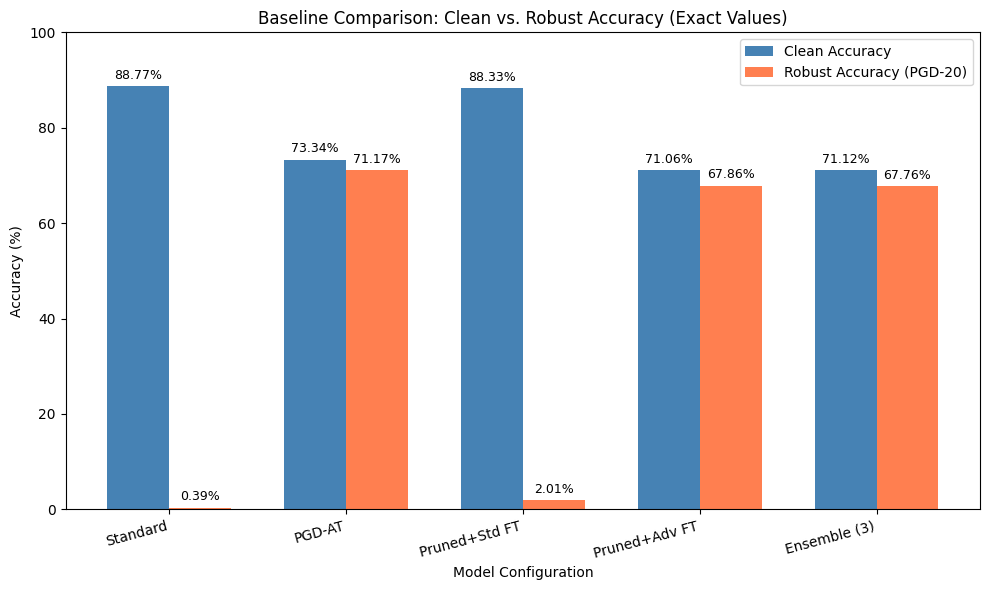

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Exact baseline results
models = ['Standard', 'PGD-AT', 'Pruned+Std FT', 'Pruned+Adv FT', 'Ensemble (3)']
clean_acc = [88.77, 73.34, 88.33, 71.06, 71.12]
robust_acc = [0.39, 71.17, 2.01, 67.86, 67.76]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, clean_acc, width, label='Clean Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, robust_acc, width, label='Robust Accuracy (PGD-20)', color='coral')

ax.set_xlabel('Model Configuration')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Baseline Comparison: Clean vs. Robust Accuracy (Exact Values)')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 100)

# Add value labels with two decimal places
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('baseline_comparison_exact.png', dpi=150)
plt.show()